# Import libs 

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


# Aufgabe 0 - Read Data

In [131]:
from pathlib import Path
import pandas as pd

csv = Path.cwd() / "minichallenge_titanic.csv"   # oder korrekten Pfad einsetzen
data = pd.read_csv(csv, sep=';', engine='python', skipinitialspace=True, na_values=['NA',''])

print(data.shape)
display(data.head())

(900, 13)


,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Aufgabe 1 - Check data 
Info: 

PassengerId

Survived 

Pclass Passenger Class

Name 

Sex

Age 

SibSp: Anzahl Geschwister oder Ehepartner:in an Bord

ParCh: Anzahl Elternteile oder Kinder an Bord

Ticket: Ticketnummer

Fare: Preis der Überfahrt

Cabin: Kabinennummer

Embarked: Einstiegshafen ("C" = Cherbourg, "Q" = Queenstown, "S" = Southampton)

In [132]:
print("rows,cols:", data.shape)
data.describe()
data.info()

rows,cols: (900, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   900 non-null    int64  
 1   PassengerId  900 non-null    int64  
 2   Survived     900 non-null    int64  
 3   Pclass       900 non-null    int64  
 4   Name         900 non-null    object 
 5   Sex          900 non-null    object 
 6   Age          723 non-null    float64
 7   SibSp        900 non-null    int64  
 8   Parch        900 non-null    int64  
 9   Ticket       900 non-null    object 
 10  Fare         900 non-null    float64
 11  Cabin        205 non-null    object 
 12  Embarked     898 non-null    object 
dtypes: float64(2), int64(6), object(5)
memory usage: 91.5+ KB


# Aufgabe 1 - Clean Data

In [133]:
# Unbenannte Spalten entfernen (z.B. wegen führendem Semikolon)
df = data.loc[:, ~data.columns.str.match(r'^Unnamed')]
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [134]:
# Passenger Id increasing? 
if len(df["PassengerId"].unique())==len(df):
    print("PassengerId is unique. No changes needed.")

PassengerId is unique. No changes needed.


In [135]:
# Survived column: 0 = No, 1 = Yes
df["Survived"].unique()
if not df["Survived"].isin([0, 1]).all():
    print("Survived column is invalid. Changes needed.")
    if df["Survived"].isNaN().any() | df["Survived"].isnull().any():
        print("Survived column contains NaN or null values. Check data for missing values.")
else: 
    print("Survived column is valid. There is no missing values. No changes needed.")


Survived column is valid. There is no missing values. No changes needed.


In [136]:
#Passenger Class 
df["Pclass"].unique()
if not df["Pclass"].isin([1, 2, 3]).all():
    print("Pclass column is invalid. Changes needed.")
    if df["Pclass"].isNaN().any() | df["Pclass"].isnull().any():
        print("Pclass column contains NaN or null values. Check data for missing values.")
else: 
    print("Pclass column is valid. There is no missing values. No changes needed.")

Pclass column is valid. There is no missing values. No changes needed.


In [137]:
#Name 
if len(df["Name"].unique()) != len(df):
    print("Name column is not unique. Search for duplicates.")
    display(df[df.duplicated(subset=["Name"], keep=False)].sort_values(by="Name"))

Name column is not unique. Search for duplicates.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
20,21,0,2,"Fynney, Mr. Joseph J",male,35.0,0,0,239865,26.0,NaN,S
891,892,0,2,"Fynney, Mr. Joseph J",male,35.0,0,0,239865,26.0,NaN,S
892,893,0,2,"Fynney, Mr. Joseph J",male,35.0,0,0,239865,26.0,NaN,S
893,894,0,2,"Fynney, Mr. Joseph J",male,35.0,0,0,239865,26.0,NaN,S
894,895,0,2,"Fynney, Mr. Joseph J",male,35.0,0,0,239865,26.0,NaN,S
895,896,0,2,"Fynney, Mr. Joseph J",male,35.0,0,0,239865,26.0,NaN,S
896,897,0,2,"Fynney, Mr. Joseph J",male,35.0,0,0,239865,26.0,NaN,S
897,898,0,2,"Fynney, Mr. Joseph J",male,35.0,0,0,239865,26.0,NaN,S


In [138]:
df = df.drop_duplicates(subset=["Name"], keep="first")
display(df)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.7500,NaN,Q
898,899,1,3,"Blately , Mrs. Martina",female,-4.0,0,3,2666,19.2583,NaN,C


In [139]:
display(df.tail(15))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,NaN,S
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S
882,883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,10.5167,NaN,S
883,884,0,2,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.5000,NaN,S
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S


In [140]:
#Sex 
df["Sex"].unique()

array(['male', 'female'], dtype=object)

In [141]:
#Age 
df["Age"].unique()
df = df.dropna(subset=["Age"])
df = df[df["Age"] >= 0]
display(df["Age"].unique())
display(df.shape)

array([22.  , 38.  , 26.  , 35.  , 54.  ,  2.  , 27.  , 14.  ,  4.  ,
       58.  , 20.  , 39.  , 55.  , 31.  , 34.  , 15.  , 28.  ,  8.  ,
       19.  , 40.  , 66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  , 49.  ,
       29.  , 65.  , 28.5 ,  5.  , 11.  , 45.  , 17.  , 32.  , 16.  ,
       25.  ,  0.83, 30.  , 33.  , 23.  , 24.  , 46.  , 59.  , 71.  ,
       37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  , 36.5 , 51.  ,
       55.5 , 40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  , 45.5 ,
       20.5 , 62.  , 41.  , 52.  , 63.  , 23.5 ,  0.92, 43.  , 60.  ,
       10.  , 64.  , 13.  , 48.  ,  0.75, 53.  , 57.  , 80.  , 70.  ,
       24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

(715, 12)

array([ 1,  0,  3,  4,  2,  5, 86])

Text(0, 0.5, 'Count')

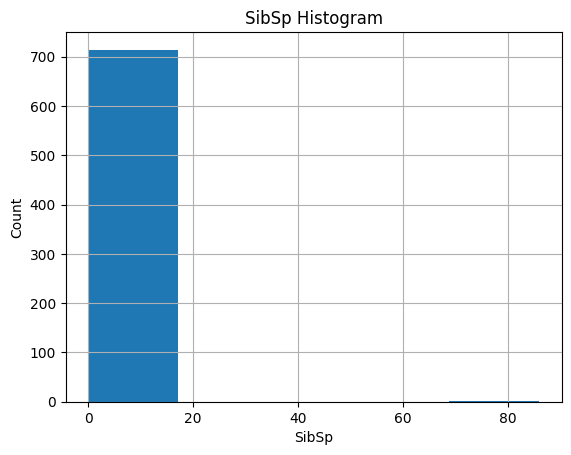

In [142]:
#SibSp
display(df["SibSp"].unique())
hist = df["SibSp"].hist(bins=5)
hist.set_title("SibSp Histogram")
hist.set_xlabel("SibSp")
hist.set_ylabel("Count")

In [143]:
SibSp_unique = df["SibSp"].unique()
SibSp_unique = df.loc[df["SibSp"] > 0, "SibSp"].unique()
SibSp_unique.sort()
print("Unique values in SibSp column:", SibSp_unique)


for n in SibSp_unique: 
    print(f"Passengers with {n} siblings/spouses aboard:")
    display(df.loc[df["SibSp"] == n].sort_values(by="Name")[["Name", "SibSp"]])


Unique values in SibSp column: [ 1  2  3  4  5 86]
Passengers with 1 siblings/spouses aboard:


,Name,SibSp
746,"Abbott, Mr. Rossmore Edward",1
279,"Abbott, Mrs. Stanton (Rosa Hunt)",1
308,"Abelson, Mr. Samuel",1
874,"Abelson, Mrs. Samuel (Hannah Wizosky)",1
40,"Ahlin, Mrs. Johan (Johanna Persdotter Larsson)",1
...,...,...
620,"Yasbeck, Mr. Antoni",1
830,"Yasbeck, Mrs. Antoni (Selini Alexander)",1
111,"Zabour, Miss. Hileni",1
559,"de Messemaeker, Mrs. Guillaume Joseph (Emma)",1


Passengers with 2 siblings/spouses aboard:


,Name,SibSp
571,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",2
644,"Baclini, Miss. Eugenie",2
469,"Baclini, Miss. Helene Barbara",2
448,"Baclini, Miss. Marie Catherine",2
183,"Becker, Master. Richard F",2
618,"Becker, Miss. Marion Louise",2
565,"Davies, Mr. Alfred J",2
436,"Ford, Miss. Doolina Margaret ""Daisy""",2
147,"Ford, Miss. Robina Maggie ""Ruby""",2
660,"Frauenthal, Dr. Henry William",2


Passengers with 3 siblings/spouses aboard:


...

,Name,SibSp
850,"Andersson, Master. Sigvard Harald Elias",4
813,"Andersson, Miss. Ebba Iris Alfrida",4
119,"Andersson, Miss. Ellis Anna Maria",4
68,"Andersson, Miss. Erna Alexandra",4
541,"Andersson, Miss. Ingeborg Constanzia",4
542,"Andersson, Miss. Sigrid Elisabeth",4
182,"Asplund, Master. Clarence Gustaf Hugo",4
261,"Asplund, Master. Edvin Rojj Felix",4
233,"Asplund, Miss. Lillian Gertrud",4
164,"Panula, Master. Eino Viljami",4


Passengers with 5 siblings/spouses aboard:


,Name,SibSp
480,"Goodwin, Master. Harold Victor",5
386,"Goodwin, Master. Sidney Leonard",5
59,"Goodwin, Master. William Frederick",5
71,"Goodwin, Miss. Lillian Amy",5
683,"Goodwin, Mr. Charles Edward",5


Passengers with 86 siblings/spouses aboard:


,Name,SibSp
899,"Grandwand, Mrs. Barbie",86


In [144]:
df['SibSp_help'] = pd.to_numeric(df['SibSp'], errors='coerce') #make sure the column is numeric, convert errors to NaN
df['SibSp_help'].unique()

array([ 1,  0,  3,  4,  2,  5, 86])

In [145]:
counts = df['SibSp_help'].value_counts().sort_index() # count occurrences of each unique value and sort by index
print(counts)

SibSp_help
0     471
1     183
2      25
3      12
4      18
5       5
86      1
Name: count, dtype: int64


In [146]:
# use IQR to find outliers in the SibSp column numerically
q1 = df['SibSp_help'].quantile(0.05) #q1 = 5th percentile (strong assumption, normally this is 25th)
q3 = df['SibSp_help'].quantile(0.95) #q3 = 95th percentile
iqr = q3 - q1
threshold_high = q3 + 1.5 * iqr
threshold_high, q1, q3, iqr

(5.749999999999886, 0.0, 2.2999999999999545, 2.2999999999999545)

In [147]:
outlier_values = np.sort(df.loc[df['SibSp_help'] > threshold_high, 'SibSp_help'].unique())
print("Numeric IQR outlier values:", outlier_values)

Numeric IQR outlier values: [86]


In [148]:
rare_values = counts[counts <= 2].index.tolist()   # 
print("Rare (count<=2):", rare_values)

Rare (count<=2): [86]


/var/folders/49/5tx076j976nf9z5phqtlg4ch0000gn/T/ipykernel_2010/3276774693.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index.astype(int), y=counts.values, palette=colors)


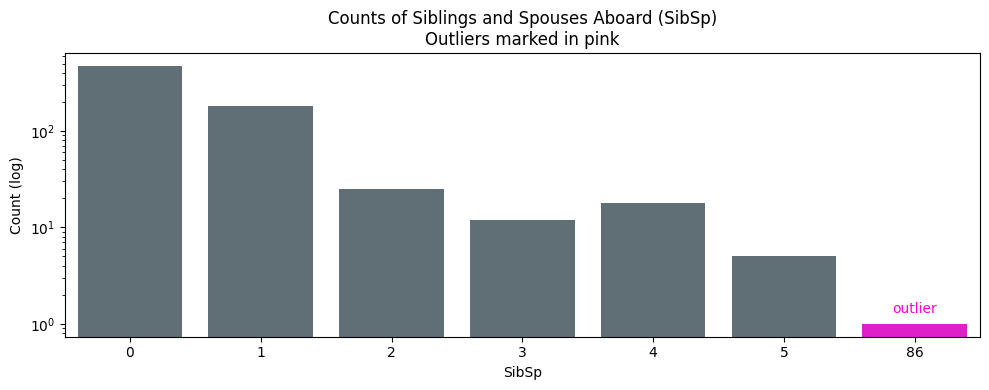

In [149]:
plt.figure(figsize=(10,4))
colors = ["#ff00e1" if v in outlier_values else "#5c7179" for v in counts.index] #define colors for the bars
ax = sns.barplot(x=counts.index.astype(int), y=counts.values, palette=colors)
plt.yscale('log') #taking logs as the counts are very skewed
plt.xlabel('SibSp'); plt.ylabel('Count (log)')
plt.title('Counts of Siblings and Spouses Aboard (SibSp)\nOutliers marked in pink')
for v in outlier_values:
    if v in counts.index:
        x_pos = list(counts.index).index(v)
        y = counts.loc[v]
        ax.annotate('outlier', xy=(x_pos, y), xytext=(0,8), textcoords='offset points', ha='center', color="#ff00e1")
plt.tight_layout(); plt.show()

In [150]:
df = df.loc[pd.to_numeric(df['SibSp'], errors='coerce') <= 5].copy()
df.tail(15)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,SibSp_help
874,875,1,2,"Abelson, Mrs. Samuel (Hannah Wizosky)",female,28.0,1,0,P/PP 3381,24.0000,NaN,C,1
875,876,1,3,"Najib, Miss. Adele Kiamie ""Jane""",female,15.0,0,0,2667,7.2250,NaN,C,0
876,877,0,3,"Gustafsson, Mr. Alfred Ossian",male,20.0,0,0,7534,9.8458,NaN,S,0
877,878,0,3,"Petroff, Mr. Nedelio",male,19.0,0,0,349212,7.8958,NaN,S,0
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C,0
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,NaN,S,0
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S,0
882,883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,10.5167,NaN,S,0
883,884,0,2,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.5000,NaN,S,0
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S,0
